# M-competition — a *sharp* ranking of forecasting methods (Step 4)

The final point on the arc **macro (null) → GJP (partial) → M-competition (sharp)**.
Ranking standard forecasting methods over the thousands of M3 series, the *same*
rank-CI pipeline delivers a decisive ordering: the top methods are pinned to exact
ranks.

**Why so sharp.** Two forces: (i) huge n (1,428 monthly series) shrinks the standard
errors; (ii) the methods are highly **correlated across series** — a hard series hurts
everyone — so each series' difficulty is a shared shock that **cancels in the sMAPE
differences**, making the paired differences far less variable than the marginals. The
method separates methods that look tied on their marginal averages.

**Structure** = same as GJP/macro: rows = series (the observation axis; unordered, so
serial dependence ~ 0 and this isolates the cross-sectional / common-shock side),
columns = methods, one sMAPE per (series, method). Data: M3 (Makridakis et al.),
auto-downloaded via `datasetsforecast`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from rankci.data.mcomp import method_panel
from rankci import (rank_ci_stepwise_pairwise,
                    rank_ci_stepwise_simulation_pairwise,
                    rank_ci_marginal_pairwise)
ALPHA = 0.10
METHODS = ["naive2", "snaive", "ets", "damped", "theta"]   # +comb added inside
pd.set_option("display.width", 170)

## 1. Build the (series x method) sMAPE panel — M3 Monthly (1,428 series)

Each series: fit on all but the last 18 points, forecast 18 ahead, score with sMAPE.
Benchmarks (Naive2, Seasonal-Naive) and serious methods (ETS, Damped-ETS, Theta) plus
their combination. (First run downloads M3 and builds the panel ~150s, then caches it.)

In [2]:
panel = method_panel(group="Monthly", methods=METHODS, metric="smape",
                     cache=True, include_comb=True)
X = panel.values
methods = list(panel.columns)
p = X.shape[1]
theta = X.mean(axis=0)
print(f"panel: {X.shape[0]} series x {p} methods")
print("mean sMAPE:", {m: round(float(t), 2) for m, t in zip(methods, theta)})

panel: 1428 series x 6 methods
mean sMAPE: {'naive2': 16.81, 'snaive': 17.24, 'ets': 17.46, 'damped': 15.84, 'theta': 13.97, 'comb': 14.99}


## 2. The ranking — rank confidence intervals

In [3]:
boot = rank_ci_stepwise_pairwise(X, alpha=ALPHA, B=1000, seed=42, verbose=False)
mds  = rank_ci_stepwise_simulation_pairwise(X, alpha=ALPHA, B=4000, seed=42, covariance="mds",   verbose=False)
om   = rank_ci_stepwise_simulation_pairwise(X, alpha=ALPHA, B=4000, seed=42, covariance="omega", verbose=False)
marg = rank_ci_marginal_pairwise(X, alpha=ALPHA, B=1000, seed=42)

tab = pd.DataFrame({
    "method":  methods,
    "mean_sMAPE": theta.round(2),
    "CI_boot":  [f"[{l},{u}]" for l, u in boot["rank_ci"]],
    "CI_mds":   [f"[{l},{u}]" for l, u in mds["rank_ci"]],
    "CI_omega": [f"[{l},{u}]" for l, u in om["rank_ci"]],
    "CI_marg":  [f"[{l},{u}]" for l, u in marg["rank_ci"]],
}).sort_values("mean_sMAPE").reset_index(drop=True)
tab.index += 1; tab.index.name = "point rank"
tab

,method,mean_sMAPE,CI_boot,CI_mds,CI_omega,CI_marg
point rank,,,,,,
1,theta,13.97,"[1,1]","[1,1]","[1,1]","[1,1]"
2,comb,14.99,"[2,2]","[2,2]","[2,2]","[2,2]"
3,damped,15.84,"[3,3]","[3,3]","[3,3]","[3,3]"
4,naive2,16.81,"[4,6]","[4,6]","[4,6]","[4,6]"
5,snaive,17.24,"[4,6]","[4,6]","[4,6]","[4,6]"
6,ets,17.46,"[4,6]","[4,6]","[4,6]","[4,6]"


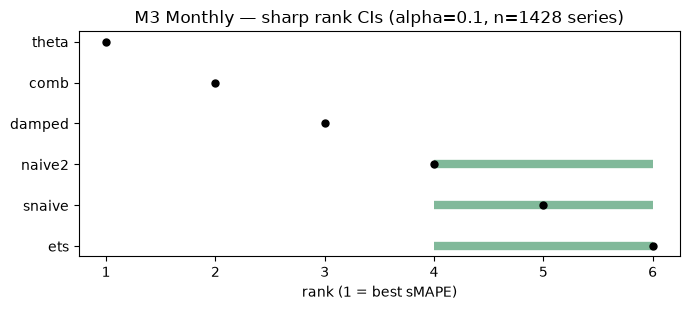

In [4]:
order = np.argsort(theta); ci = om["rank_ci"][order]; yy = np.arange(p)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hlines(yy, ci[:, 0], ci[:, 1], color="seagreen", lw=6, alpha=0.6)
ax.plot(np.arange(1, p + 1), yy, "o", color="black", ms=5)
ax.set_yticks(yy); ax.set_yticklabels([methods[i] for i in order]); ax.invert_yaxis()
ax.set_xlabel("rank (1 = best sMAPE)"); ax.set_xticks(range(1, p + 1))
ax.set_title(f"M3 Monthly — sharp rank CIs (alpha={ALPHA}, n={X.shape[0]} series)")
fig.tight_layout(); plt.show()

## 3. Robustness across frequencies

Theta > Comb > Damped is stable across Monthly / Quarterly / Yearly; sharpness scales
with the number of series.

In [5]:
rows = []
for g in ["Monthly", "Quarterly", "Yearly"]:
    pn = method_panel(group=g, methods=METHODS, cache=True, include_comb=True)
    th = pn.values.mean(axis=0); od = np.argsort(th)
    o = rank_ci_stepwise_simulation_pairwise(pn.values, alpha=ALPHA, B=3000, seed=42,
                                             covariance="omega", verbose=False)
    w = (o["rank_ci"][:, 1] - o["rank_ci"][:, 0]).mean()
    rows.append({"group": g, "n_series": pn.shape[0],
                 "order (best->worst)": " > ".join(pn.columns[j] for j in od),
                 "mean_CI_width": round(float(w), 2)})
pd.DataFrame(rows).set_index("group")

,n_series,order (best->worst),mean_CI_width
group,,,
Monthly,1428,theta > comb > damped > naive2 > snaive > ets,1.00
Quarterly,756,theta > comb > damped > naive2 > ets > snaive,1.67
Yearly,645,theta > comb > damped > naive2 > snaive > ets,3.00


## 4. The three regimes — one method, one figure

Same `rankci` pipeline on three panels. Normalised CI width (mean width / (p-1)) and
the fraction of methods/forecasters pinned to an exact rank make the contrast explicit.

In [6]:
from rankci import select_top_forecasters
from rankci.data.philly import load_spf, load_rtdsm, compute_error_panel
from rankci.data.gjp import load_gjp_ifps, load_gjp_forecasts, brier_panel

# macro (NGDP, top 8)
spf = load_spf("../../data/philly/SPFmicrodata.xlsx", sheet="NGDP")
rt  = load_rtdsm("../../data/philly/NOUTPUTQvQd.xlsx", prefix="NOUTPUT")
Xmac = select_top_forecasters(compute_error_panel(spf, rt, "NGDP", 3, "squared"), N=8, min_obs=20).values
# GJP (top 20, yr1+2)
ifps = load_gjp_ifps("../../data/gjp/ifps.csv")
gfc  = load_gjp_forecasts(["../../data/gjp/survey_fcasts.yr1.csv", "../../data/gjp/survey_fcasts.yr2.csv"])
Xgjp, _ = brier_panel(gfc, ifps, condition="individual", min_questions=60, top_n=20, years=[1, 2])
Xgjp = Xgjp.values
# M-comp (Monthly)
Xmc = X

def summarise(name, Xp):
    o = rank_ci_stepwise_simulation_pairwise(Xp, alpha=ALPHA, B=3000, seed=42,
                                             covariance="omega", verbose=False)
    ci = o["rank_ci"]; pp = Xp.shape[1]
    return {"dataset": name, "p": pp, "n_obs": Xp.shape[0],
            "norm_width": round(float((ci[:, 1] - ci[:, 0]).mean() / (pp - 1)), 2),
            "frac_separated": round(float(((ci[:, 0] > 1) | (ci[:, 1] < pp)).mean()), 2),
            "n_exact_ranks": int((ci[:, 0] == ci[:, 1]).sum())}

pd.DataFrame([summarise("macro (NGDP)", Xmac),
              summarise("GJP (geopolitical)", Xgjp),
              summarise("M-comp (Monthly)", Xmc)]).set_index("dataset")

,p,n_obs,norm_width,frac_separated,n_exact_ranks
dataset,,,,,
macro (NGDP),8,225,1.00,0.0,0
GJP (geopolitical),20,212,0.73,1.0,1
M-comp (Monthly),6,1428,0.20,1.0,3


## Summary

- **Sharp and non-obvious.** On 1,428 monthly M3 series the ranking is decisive:
  **Theta** is confidently best (rank `[1,1]`, recovering the famous M3 result), the
  **combination** second, **Damped-ETS** third; the three simple benchmarks form a tie
  group. Mean rank-CI width ~1 of 5. Stable across frequencies.
- **The method's core value on display.** Theta and the combination differ by ~1 sMAPE
  point on the marginals, yet are separated with confidence — because the paired
  differences (after the shared per-series difficulty cancels) have far smaller
  variance. This is exactly what difference-based rank inference buys.
- **One method, three regimes.** The identical covariance-estimation pipeline feeding
  MRSW reports: macro forecasters *indistinguishable* (`[1,p]`), GJP forecasters
  *partially* separable (top tier only), M-competition methods *sharply* ordered. The
  width of the confidence set is an honest read of how much the data can support.

## 5. Thesis application — the official M3 submissions on the Paris temperature record

Every number quoted in the thesis section *Forecasting methods on the M3 competition*
(`sec:apps-mcomp`) is produced below. Unlike §§1–4 (methods we re-implemented), this
uses the forecasts the **24 M3 competitors actually submitted**, with the held-out
actuals, from the CRAN package `Mcomp` 2.8 (downloaded once, checksum-verified, read
with `rdata`).

The indicator is the **monthly mean temperature in Paris**: 17 consecutive
non-overlapping 8-year blocks (series N2784–N2800, 1857–1992); each block is fit on 78
months and forecast 18 ahead. Rows = (block, horizon) in calendar order → n = 306;
columns = methods → p = 24; loss = sMAPE point (the competition's metric).

In [7]:
from rankci.data.mcomp import load_m3_official, official_panel
from rankci import rank_ci_marginal_pairwise, tau_best_simulation_pairwise, andrews_bandwidth

PARIS = "Average temperature in Paris"
long = load_m3_official(directory="../../data/mcomp")
blocks = long[long.description == PARIS].groupby("series", sort=False)
print("blocks:", blocks.ngroups, "| held-out months per block:", blocks.size().unique(),
      "| held-out value range:", long.loc[long.description == PARIS, "actual"].agg(["min", "max"]).tolist())

P = official_panel(PARIS, directory="../../data/mcomp")
Xp = P.values; mp = list(P.columns); pp = Xp.shape[1]
thp = Xp.mean(0); odp = np.argsort(thp)
print(f"panel: {Xp.shape[0]} (block, horizon) rows x {pp} methods")

blocks: 17 | held-out months per block: [18] | held-out value range: [1200.0, 11400.0]
panel: 306 (block, horizon) rows x 24 methods


### 5.1 Rank confidence sets (thesis Table `tab:mcomp`, Figure `fig:mcomp-caterpillar`)

In [8]:
A = 0.10
ci = {
    "omega": rank_ci_stepwise_simulation_pairwise(Xp, alpha=A, B=20000, seed=42, covariance="omega", verbose=False),
    "mds":   rank_ci_stepwise_simulation_pairwise(Xp, alpha=A, B=20000, seed=42, covariance="mds", verbose=False),
    "boot":  rank_ci_stepwise_pairwise(Xp, alpha=A, B=5000, seed=42, verbose=False),
    "marg":  rank_ci_marginal_pairwise(Xp, alpha=A, B=5000, seed=42),
}
fmt = lambda c: [f"[{l},{u}]" for l, u in c]
tabp = pd.DataFrame({"method": np.array(mp)[odp], "mean_sMAPE": thp[odp].round(2),
                     **{k: fmt(v["rank_ci"][odp]) for k, v in ci.items()}})
tabp.index = np.arange(1, pp + 1); tabp.index.name = "point rank"

def width_summary(c):
    w = c[:, 1] - c[:, 0]
    return {"norm_width": round(w.mean() / (pp - 1), 2), "mean_width": round(w.mean(), 1),
            "exact": int((w == 0).sum()), "excluded_from_best": int((c[:, 0] > 1).sum())}
display(pd.DataFrame({k: width_summary(v["rank_ci"]) for k, v in ci.items()}).T)
tabp

,norm_width,mean_width,exact,excluded_from_best
omega,0.59,13.6,0.0,12.0
mds,0.60,13.8,0.0,12.0
boot,0.61,13.9,0.0,12.0
marg,0.55,12.5,0.0,13.0


,method,mean_sMAPE,omega,mds,boot,marg
point rank,,,,,,
1,B-J auto,10.10,"[1,12]","[1,12]","[1,12]","[1,12]"
2,ForecastPro,10.13,"[1,12]","[1,12]","[1,13]","[1,12]"
3,ForcX,10.39,"[1,15]","[1,15]","[1,15]","[1,15]"
4,DAMPEN,10.45,"[1,16]","[1,17]","[1,17]","[1,15]"
5,COMB S-H-D,10.46,"[1,15]","[1,15]","[1,15]","[1,14]"
6,THETA,10.50,"[1,16]","[1,16]","[1,16]","[1,15]"
7,WINTER,10.66,"[1,18]","[1,18]","[1,19]","[1,15]"
8,HOLT,10.86,"[1,19]","[1,19]","[1,19]","[1,19]"
9,SINGLE,10.92,"[1,20]","[1,21]","[1,21]","[2,19]"


### 5.2 Dependence in the panel (thesis `sec:apps-mcomp-dependence`)

In [9]:
pairs = [(j, k) for j in range(pp) for k in range(j + 1, pp)]
C = np.corrcoef(Xp.T)
cancel = [1 - np.var(Xp[:, j] - Xp[:, k]) / (np.var(Xp[:, j]) + np.var(Xp[:, k])) for j, k in pairs]
r1 = [np.corrcoef(d[:-1], d[1:])[0, 1] for d in (Xp[:, j] - Xp[:, k] for j, k in pairs)]
L = [andrews_bandwidth(Xp[:, j] - Xp[:, k]) for j, k in pairs]
print(f"mean pairwise loss correlation : {C[np.triu_indices(pp, 1)].mean():.2f}")
print(f"median variance share cancelled: {np.median(cancel):.2f}   (1 - Var(d)/(Var X_j + Var X_k))")
print(f"median lag-1 autocorr of d     : {np.nanmedian(r1):.2f}")
print(f"Andrews bandwidth              : median {np.median(L):.0f}, range {min(L)}-{max(L)}")

mean pairwise loss correlation : 0.65
median variance share cancelled: 0.65   (1 - Var(d)/(Var X_j + Var X_k))
median lag-1 autocorr of d     : 0.13
Andrews bandwidth              : median 3, range 0-19


### 5.3 How informative: τ-best set, ordered pairs, and the failures

In [10]:
om = ci["omega"]
tb = tau_best_simulation_pairwise(Xp, tau=1, alpha=A, B=20000, seed=42, verbose=False)
print("tau-best (tau=1) set:", [mp[j] for j in np.where(tb["tau_best_set"])[0]])

ordered = {tuple(sorted(x)) for x in om["rejected"]}
print(f"confidently ordered pairs: {len(ordered)} of {len(pairs)}")
groups = {"top": set(np.where(om["rank_ci"][:, 0] == 1)[0]),
          "bottom": set(odp[-3:])}
groups["middle"] = set(range(pp)) - groups["top"] - groups["bottom"]
names = ["top", "middle", "bottom"]
for a_i, a in enumerate(names):
    for b in names[a_i:]:
        A_, B_ = groups[a], groups[b]
        n_all = len(A_) * (len(A_) - 1) // 2 if a == b else len(A_) * len(B_)
        n_ord = sum(1 for (x, y) in ordered if (x in A_ and y in B_) or (x in B_ and y in A_))
        print(f"  {a:>6} vs {b:<6}: {n_ord:3d} / {n_all}")

tau-best (tau=1) set: ['SINGLE', 'HOLT', 'DAMPEN', 'WINTER', 'COMB S-H-D', 'B-J auto', 'PP-Autocast', 'ForecastPro', 'SMARTFCS', 'THETA', 'RBF', 'ForcX']
confidently ordered pairs: 113 of 276
     top vs top   :   0 / 66
     top vs middle:  48 / 108
     top vs bottom:  36 / 36
  middle vs middle:   1 / 36
  middle vs bottom:  27 / 27
  bottom vs bottom:   1 / 3


In [11]:
# block-level view: why the bottom three fail, and why PP-Autocast is unrankable
per_block = P.groupby(level="series", sort=False).mean()
flat = long[long.description == PARIS].groupby("series", sort=False)[["Flors-Pearc1", "Flors-Pearc2"]].std() == 0
print("blocks with a constant (non-seasonal) forecast:", flat.sum().to_dict())
print("Robust-Trend blocks with sMAPE > 25:", int((per_block["ROBUST-Trend"] > 25).sum()))
per_block[["B-J auto", "ForecastPro", "THETA", "PP-Autocast", "ROBUST-Trend", "Flors-Pearc1", "Flors-Pearc2"]].round(1)

blocks with a constant (non-seasonal) forecast: {'Flors-Pearc1': 12, 'Flors-Pearc2': 12}
Robust-Trend blocks with sMAPE > 25: 8


,B-J auto,ForecastPro,THETA,PP-Autocast,ROBUST-Trend,Flors-Pearc1,Flors-Pearc2
series,,,,,,,
N2784,11.6,11.6,11.7,12.5,60.4,43.2,37.2
N2785,15.3,15.3,15.3,16.9,35.9,37.0,33.9
N2786,18.1,18.1,19.0,20.3,21.4,40.6,43.9
N2787,12.2,12.2,12.5,12.4,27.0,50.3,40.7
N2788,12.5,12.8,11.9,11.9,46.9,40.0,34.0
N2789,9.1,9.3,9.0,9.3,9.1,38.2,9.0
N2790,13.3,13.3,14.4,13.1,59.2,35.8,28.0
N2791,11.7,11.7,12.5,12.2,11.5,38.1,30.8
N2792,6.5,6.1,7.1,8.6,6.7,33.8,29.7


### 5.4 Robustness: α = 0.05, and one observation per block

In [12]:
o05 = rank_ci_stepwise_simulation_pairwise(Xp, alpha=0.05, B=20000, seed=42, covariance="omega", verbose=False)["rank_ci"]
Xb = per_block.values                                   # n = 17 block averages
ob = rank_ci_stepwise_simulation_pairwise(Xb, alpha=A, B=20000, seed=42, covariance="omega", verbose=False)["rank_ci"]
pd.DataFrame({"method": np.array(mp)[odp],
              "omega a=0.10": fmt(om["rank_ci"][odp]),
              "omega a=0.05": fmt(o05[odp]),
              "per-block (n=17)": fmt(ob[odp])}, index=np.arange(1, pp + 1))

,method,omega a=0.10,omega a=0.05,per-block (n=17)
1,B-J auto,"[1,12]","[1,13]","[1,14]"
2,ForecastPro,"[1,12]","[1,14]","[1,15]"
3,ForcX,"[1,15]","[1,16]","[1,16]"
4,DAMPEN,"[1,16]","[1,17]","[1,16]"
5,COMB S-H-D,"[1,15]","[1,16]","[1,17]"
6,THETA,"[1,16]","[1,17]","[1,16]"
7,WINTER,"[1,18]","[1,19]","[1,17]"
8,HOLT,"[1,19]","[1,20]","[1,20]"
9,SINGLE,"[1,20]","[1,21]","[1,18]"
10,RBF,"[1,20]","[1,21]","[1,20]"


**Summary (thesis wording).** On this single, inherently forecastable indicator the
ranking is informative at both ends but not in the middle: twelve methods share rank
one (the τ-best set) and cannot be ordered among themselves, the other twelve are
confidently excluded from first place, and three systematic failures — the two
Flores–Pearce expert systems (constant forecasts in most blocks) and Robust-Trend —
are pinned to the last three ranks. MDS and Ω agree to within one rank, as the
balanced-panel equivalence predicts. (The thesis reports only these two simulation
routes; the bootstrap and marginal columns of §5.1 are kept here for reference.)